# 11 — VaR Backtest

Notebooks 09 and 10 built a risk engine and checked it was *internally* consistent — the compensator keeps drift unbiased, jumps reproduce the observed kurtosis. None of that establishes the numbers are right in absolute terms.

This notebook asks the only question that does:

> **When the engine said 'you will lose at most X with 95% confidence', how often was it wrong?**

A VaR95% should be breached about **5%** of the time. Materially more and the engine understates risk, which is the dangerous direction — users would be blindsided by losses the model called improbable. Materially less and it overstates risk, making the numbers useless for decisions.

**This is the last check before anything is shown to a user.** An engine that produces confident, well-formatted, miscalibrated numbers is worse than no engine, because it invites trust it has not earned.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

In [2]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.data.loader import PROCESSED_FEATURES_PATH, load_processed_features

data = load_processed_features()
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values(["symbol", "date"]).reset_index(drop=True)
data["log_return"] = data.groupby("symbol")["adj_close"].transform(
    lambda s: np.log(s / s.shift(1))
)

print(f'Loaded {len(data):,} rows for {data["symbol"].nunique():,} tickers')
print(f'Source: {PROCESSED_FEATURES_PATH}')
data.head()

Loaded 622,731 rows for 502 tickers
Source: D:\StockForecastRisk\data\processed\sp500_features.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,...,quarter,ticker_id,sector_id,sector_avg_return_20d,relative_strength_sector_20d,days_to_next_earnings,future_return,future_direction,future_realized_vol,log_return
0,2021-07-19,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,142.434052,147.580002,147.970001,146.949997,147.660004,...,3,0,5,NaN,NaN,29.0,0.017930,1,0.011389,NaN
1,2021-07-20,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,144.094101,149.300003,151.250000,147.830002,148.449997,...,3,0,5,NaN,NaN,28.0,0.004344,1,0.010595,0.011587
2,2021-07-21,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,143.756302,148.949997,149.910004,147.600006,149.490005,...,3,0,5,NaN,NaN,27.0,0.016711,1,0.011089,-0.002347
3,2021-07-22,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,145.059174,150.300003,150.500000,148.669998,149.710007,...,3,0,5,NaN,NaN,26.0,0.015645,1,0.010962,0.009022
4,2021-07-23,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,146.999084,152.309998,152.410004,150.429993,150.589996,...,3,0,5,NaN,NaN,25.0,0.006022,1,0.009477,0.013285


In [3]:
TRADING_DAYS = 252          # number of trading days in a year
HORIZON_DAYS = 21          # ~one month ahead
CONFIDENCE = 0.95
MIN_HISTORY = 252          # at least a year before the first forecast
STEP_DAYS = 5              # re-forecast weekly rather than daily
N_PATHS = 4_000
DRIFT = 0.04               # risk-free, matching notebook 10's default


def fit_parameters(log_returns, k=3.0, trading_days=TRADING_DAYS):
    """Iterative threshold fit -- same estimator as notebook 09."""
    values = np.asarray(log_returns, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 60:
        return None

    mean, sigma = values.mean(), values.std(ddof=1)
    for _ in range(10):
        is_jump = np.abs(values - mean) > k * sigma
        core = values[~is_jump]
        if len(core) < 30:
            break
        new_mean, new_sigma = core.mean(), core.std(ddof=1)
        converged = abs(new_sigma - sigma) < 1e-10
        mean, sigma = new_mean, new_sigma
        if converged:
            break

    is_jump = np.abs(values - mean) > k * sigma
    jumps = values[is_jump]
    return {
        "sigma": sigma * np.sqrt(trading_days),
        "lam": is_jump.sum() / len(values) * trading_days,
        "jump_mean": jumps.mean() if len(jumps) else 0.0,
        "jump_std": jumps.std(ddof=1) if len(jumps) > 1 else 0.0,
    }


def forecast_var(params, horizon, confidence, mu=DRIFT, n_paths=N_PATHS,
                 seed=0, trading_days=TRADING_DAYS):
    """Simulate forward and return the VaR as a positive loss fraction."""
    rng = np.random.default_rng(seed)
    dt = 1.0 / trading_days
    kappa = np.exp(params["jump_mean"] + 0.5 * params["jump_std"] ** 2) - 1.0
    drift = (mu - 0.5 * params["sigma"] ** 2 - params["lam"] * kappa) * dt

    diffusion = params["sigma"] * np.sqrt(dt) * rng.standard_normal((n_paths, horizon))
    counts = rng.poisson(params["lam"] * dt, (n_paths, horizon))
    jumps = np.where(
        counts > 0,
        rng.normal(params["jump_mean"] * counts,
                   max(params["jump_std"], 1e-12) * np.sqrt(np.maximum(counts, 1))),
        0.0,
    )
    terminal = np.exp(np.cumsum(drift + diffusion + jumps, axis=1))[:, -1]
    return -np.quantile(terminal - 1.0, 1 - confidence)

In [4]:
def backtest_symbol(group, horizon=HORIZON_DAYS, confidence=CONFIDENCE):
    """Rolling point-in-time VaR forecasts and their realised outcomes."""
    group = group.dropna(subset=["log_return"]).reset_index(drop=True)
    records = []

    for position in range(MIN_HISTORY, len(group) - horizon, STEP_DAYS):
        history = group["log_return"].iloc[:position].values      # past only
        params = fit_parameters(history)
        if params is None:
            continue

        var = forecast_var(params, horizon, confidence, seed=position)
        realised = np.exp(group["log_return"].iloc[position:position + horizon].sum()) - 1.0

        records.append({
            "date": group["date"].iloc[position],
            "var": var,
            "realised_return": realised,
            "breach": realised < -var,
        })

    return pd.DataFrame(records)


BACKTEST_SYMBOLS = list(data["symbol"].unique()[:50])

backtests = {}
for symbol in BACKTEST_SYMBOLS:
    result = backtest_symbol(data[data["symbol"] == symbol])
    if not result.empty:
        backtests[symbol] = result
    print(f"{symbol}: {len(result)} forecast windows")

A: 197 forecast windows
AAPL: 197 forecast windows
ABBV: 197 forecast windows
ABNB: 197 forecast windows
ABT: 197 forecast windows
ACGL: 197 forecast windows
ACN: 197 forecast windows
ADBE: 197 forecast windows
ADI: 197 forecast windows
ADM: 197 forecast windows
ADP: 197 forecast windows
ADSK: 197 forecast windows
AEE: 197 forecast windows
AEP: 197 forecast windows
AES: 197 forecast windows
AFL: 197 forecast windows
AIG: 197 forecast windows
AIZ: 197 forecast windows
AJG: 197 forecast windows
AKAM: 197 forecast windows
ALB: 197 forecast windows
ALGN: 197 forecast windows
ALL: 197 forecast windows
ALLE: 197 forecast windows
AMAT: 197 forecast windows
AMCR: 197 forecast windows
AMD: 197 forecast windows
AME: 197 forecast windows
AMGN: 197 forecast windows
AMP: 197 forecast windows
AMT: 197 forecast windows
AMZN: 197 forecast windows
ANET: 197 forecast windows
AON: 197 forecast windows
AOS: 197 forecast windows
APA: 197 forecast windows
APD: 197 forecast windows
APH: 197 forecast windows


In [5]:
def kupiec_test(n_observations, n_breaches, expected_rate):
    """Proportion-of-failures likelihood ratio test."""
    if n_breaches == 0 or n_observations == 0:
        return np.nan, np.nan
    observed_rate = n_breaches / n_observations
    if observed_rate in (0.0, 1.0):
        return np.nan, np.nan

    log_likelihood_null = (
        (n_observations - n_breaches) * np.log(1 - expected_rate)
        + n_breaches * np.log(expected_rate)
    )
    log_likelihood_alt = (
        (n_observations - n_breaches) * np.log(1 - observed_rate)
        + n_breaches * np.log(observed_rate)
    )
    statistic = -2 * (log_likelihood_null - log_likelihood_alt)
    return statistic, 1 - stats.chi2.cdf(statistic, 1)


expected_rate = 1 - CONFIDENCE
summary_rows = []
for symbol, result in backtests.items():
    n = len(result)
    breaches = int(result["breach"].sum())
    statistic, p_value = kupiec_test(n, breaches, expected_rate)
    summary_rows.append({
        "symbol": symbol,
        "windows": n,
        "breaches": breaches,
        "breach_rate": breaches / n if n else np.nan,
        "kupiec_p": p_value,
        "calibrated": bool(p_value > 0.05) if not np.isnan(p_value) else None,
    })

calibration = pd.DataFrame(summary_rows).set_index("symbol")
print(f"expected breach rate: {expected_rate:.1%}\n")
display(calibration.round(4))

expected breach rate: 5.0%



,windows,breaches,breach_rate,kupiec_p,calibrated
symbol,,,,,
A,197,8,0.0406,0.5324,True
AAPL,197,2,0.0102,0.0019,False
ABBV,197,8,0.0406,0.5324,True
ABNB,197,2,0.0102,0.0019,False
ABT,197,10,0.0508,0.9610,True
ACGL,197,3,0.0152,0.0090,False
ACN,197,19,0.0964,0.0076,False
ADBE,197,11,0.0558,0.7119,True
ADI,197,5,0.0254,0.0810,True


In [6]:
def christoffersen_independence(breaches):
    """Likelihood ratio test for serial independence of breaches."""
    sequence = np.asarray(breaches).astype(int)
    if len(sequence) < 2:
        return np.nan, np.nan

    n00 = n01 = n10 = n11 = 0
    for previous, current in zip(sequence[:-1], sequence[1:]):
        if previous == 0 and current == 0:
            n00 += 1
        elif previous == 0 and current == 1:
            n01 += 1
        elif previous == 1 and current == 0:
            n10 += 1
        else:
            n11 += 1

    total = n00 + n01 + n10 + n11
    if total == 0 or (n01 + n11) == 0:
        return np.nan, np.nan

    pi = (n01 + n11) / total
    pi_0 = n01 / (n00 + n01) if (n00 + n01) else 0.0
    pi_1 = n11 / (n10 + n11) if (n10 + n11) else 0.0

    def log_likelihood(p, zeros, ones):
        if p <= 0 or p >= 1:
            return 0.0
        return zeros * np.log(1 - p) + ones * np.log(p)

    statistic = -2 * (
        log_likelihood(pi, n00 + n10, n01 + n11)
        - (log_likelihood(pi_0, n00, n01) + log_likelihood(pi_1, n10, n11))
    )
    return statistic, 1 - stats.chi2.cdf(statistic, 1)


independence_rows = []
for symbol, result in backtests.items():
    statistic, p_value = christoffersen_independence(result["breach"].values)
    independence_rows.append({
        "symbol": symbol,
        "christoffersen_p": p_value,
        "independent": bool(p_value > 0.05) if not np.isnan(p_value) else None,
    })

independence = pd.DataFrame(independence_rows).set_index("symbol")
display(independence.round(4))
print("NaN means too few breaches to test -- not a failure, just no evidence either way.")

,christoffersen_p,independent
symbol,,
A,0.0300,False
AAPL,0.8391,True
ABBV,0.0300,False
ABNB,0.0081,False
ABT,0.0000,False
ACGL,0.0260,False
ACN,0.0000,False
ADBE,0.0000,False
ADI,0.6089,True


NaN means too few breaches to test -- not a failure, just no evidence either way.


In [7]:
verdict = calibration.join(independence)

pooled_windows = int(verdict["windows"].sum())
pooled_breaches = int(verdict["breaches"].sum())
pooled_rate = pooled_breaches / pooled_windows if pooled_windows else np.nan
pooled_statistic, pooled_p = kupiec_test(pooled_windows, pooled_breaches, expected_rate)

print(f"Pooled across {len(verdict)} symbols:")
print(f"  windows        : {pooled_windows:,}")
print(f"  breaches       : {pooled_breaches:,}")
print(f"  breach rate    : {pooled_rate:.3%}   (expected {expected_rate:.1%})")
print(f"  Kupiec p-value : {pooled_p:.4f}")

if np.isnan(pooled_p):
    print("\n  Too few breaches to judge.")
elif pooled_p > 0.05:
    print("\n  WELL CALIBRATED -- the breach rate is consistent with the model's claim.")
elif pooled_rate > expected_rate:
    print("\n  UNDERSTATES RISK -- more breaches than promised. This is the dangerous")
    print("  direction: losses the model called improbable happen too often.")
else:
    print("\n  OVERSTATES RISK -- fewer breaches than promised. Safe, but the numbers")
    print("  are too conservative to be useful for decisions.")

display(verdict.round(4))

Pooled across 50 symbols:
  windows        : 9,850
  breaches       : 345
  breach rate    : 3.503%   (expected 5.0%)
  Kupiec p-value : 0.0000

  OVERSTATES RISK -- fewer breaches than promised. Safe, but the numbers
  are too conservative to be useful for decisions.


,windows,breaches,breach_rate,kupiec_p,calibrated,christoffersen_p,independent
symbol,,,,,,,
A,197,8,0.0406,0.5324,True,0.0300,False
AAPL,197,2,0.0102,0.0019,False,0.8391,True
ABBV,197,8,0.0406,0.5324,True,0.0300,False
ABNB,197,2,0.0102,0.0019,False,0.0081,False
ABT,197,10,0.0508,0.9610,True,0.0000,False
ACGL,197,3,0.0152,0.0090,False,0.0260,False
ACN,197,19,0.0964,0.0076,False,0.0000,False
ADBE,197,11,0.0558,0.7119,True,0.0000,False
ADI,197,5,0.0254,0.0810,True,0.6089,True


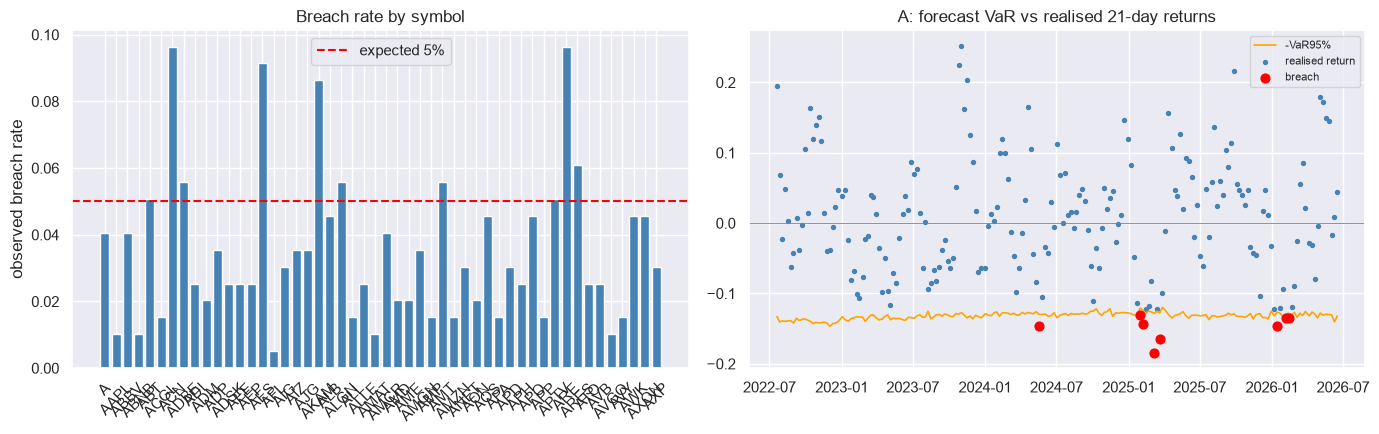

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].bar(verdict.index, verdict["breach_rate"], color="steelblue")
axes[0].axhline(expected_rate, color="red", linestyle="--", linewidth=1.5,
                label=f"expected {expected_rate:.0%}")
axes[0].set_title("Breach rate by symbol")
axes[0].set_ylabel("observed breach rate")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

example = list(backtests)[0]
series = backtests[example]
axes[1].plot(series["date"], -series["var"], color="orange", linewidth=1.2,
             label=f"-VaR{CONFIDENCE:.0%}")
axes[1].scatter(series["date"], series["realised_return"], s=8, color="steelblue",
                label="realised return")
breached = series[series["breach"]]
axes[1].scatter(breached["date"], breached["realised_return"], s=40, color="red",
                zorder=3, label="breach")
axes[1].axhline(0, color="grey", linewidth=0.6)
axes[1].set_title(f"{example}: forecast VaR vs realised {HORIZON_DAYS}-day returns")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
def ewma_sigma(log_returns, decay=0.94, lookback=250):
    """RiskMetrics EWMA volatility, annualised."""
    values = np.asarray(log_returns, dtype=float)
    values = values[np.isfinite(values)][-lookback:]
    if len(values) < 30:
        return np.nan
    variance = np.var(values, ddof=1)
    for value in values:
        variance = decay * variance + (1 - decay) * value ** 2
    return float(np.sqrt(variance * TRADING_DAYS))


SIGMA_REGIMES = {
    "static": lambda params, history: params["sigma"],
    "ewma": lambda params, history: ewma_sigma(history),
    "blend": lambda params, history: 0.5 * params["sigma"] + 0.5 * ewma_sigma(history),
}


def backtest_with_sigma(group, sigma_fn, horizon=HORIZON_DAYS, confidence=CONFIDENCE):
    group = group.dropna(subset=["log_return"]).reset_index(drop=True)
    breaches = []
    for position in range(MIN_HISTORY, len(group) - horizon, STEP_DAYS):
        history = group["log_return"].iloc[:position].values
        params = fit_parameters(history)
        if params is None:
            continue
        sigma = sigma_fn(params, history)
        if not np.isfinite(sigma) or sigma <= 0:
            sigma = params["sigma"]          # fall back rather than skip
        adjusted = dict(params, sigma=sigma)
        var = forecast_var(adjusted, horizon, confidence, seed=position)
        realised = np.exp(group["log_return"].iloc[position:position + horizon].sum()) - 1.0
        breaches.append(realised < -var)
    return np.array(breaches)


regime_rows = []
for regime_name, sigma_fn in SIGMA_REGIMES.items():
    total_windows = total_breaches = 0
    kupiec_passes = independence_passes = tested = 0
    for symbol in BACKTEST_SYMBOLS:
        breaches = backtest_with_sigma(data[data["symbol"] == symbol], sigma_fn)
        if len(breaches) == 0:
            continue
        total_windows += len(breaches)
        total_breaches += int(breaches.sum())
        _, k_p = kupiec_test(len(breaches), int(breaches.sum()), expected_rate)
        _, c_p = christoffersen_independence(breaches)
        tested += 1
        kupiec_passes += int(k_p > 0.05) if not np.isnan(k_p) else 0
        independence_passes += int(c_p > 0.05) if not np.isnan(c_p) else 0
    _, pooled_k = kupiec_test(total_windows, total_breaches, expected_rate)
    regime_rows.append({
        "regime": regime_name,
        "pooled_rate": total_breaches / total_windows,
        "pooled_kupiec_p": pooled_k,
        "kupiec_pass": f"{kupiec_passes}/{tested}",
        "independence_pass": f"{independence_passes}/{tested}",
    })

regime_comparison = pd.DataFrame(regime_rows).set_index("regime")
print(f"expected breach rate {expected_rate:.1%}; "
      f"'independence_pass' is the conditional-coverage result.\n")
display(regime_comparison.round(4))

expected breach rate 5.0%; 'independence_pass' is the conditional-coverage result.



,pooled_rate,pooled_kupiec_p,kupiec_pass,independence_pass
regime,,,,
static,0.0350,0.0,30/50,12/50
ewma,0.0337,0.0,33/50,14/50
blend,0.0329,0.0,31/50,13/50


In [10]:
def backtest_variant(symbols, k=3.0, mu=DRIFT, jump_scale=1.0, horizon=HORIZON_DAYS):
    """Run the backtest with one parameter varied. Returns (windows, breaches)."""
    total = breaches = 0
    for symbol in symbols:
        group = data[data["symbol"] == symbol].dropna(subset=["log_return"]).reset_index(drop=True)
        for position in range(MIN_HISTORY, len(group) - horizon, STEP_DAYS):
            history = group["log_return"].iloc[:position].values
            params = fit_parameters(history, k=k)
            if params is None:
                continue
            scaled = dict(params, lam=params["lam"] * jump_scale)
            var = forecast_var(scaled, horizon, CONFIDENCE, mu=mu, seed=position)
            realised = np.exp(group["log_return"].iloc[position:position + horizon].sum()) - 1.0
            total += 1
            breaches += int(realised < -var)
    return total, breaches


variants = [
    ("baseline",                dict()),
    ("drift: zero",             dict(mu=0.0)),
    ("drift: market 8%",        dict(mu=0.08)),
    ("jumps: k=2.5 (more)",     dict(k=2.5)),
    ("jumps: k=4.0 (fewer)",    dict(k=4.0)),
    ("jumps: half intensity",   dict(jump_scale=0.5)),
    ("jumps: none",             dict(jump_scale=0.0)),
]

diagnostic_rows = []
for label, kwargs in variants:
    total, breaches = backtest_variant(BACKTEST_SYMBOLS, **kwargs)
    _, p_value = kupiec_test(total, breaches, expected_rate)
    diagnostic_rows.append({
        "variant": label,
        "windows": total,
        "breach_rate": breaches / total if total else np.nan,
        "kupiec_p": p_value,
    })

diagnostics = pd.DataFrame(diagnostic_rows).set_index("variant")
baseline_rate = diagnostics.loc["baseline", "breach_rate"]
diagnostics["vs_baseline_pp"] = (diagnostics["breach_rate"] - baseline_rate) * 100

print(f"expected breach rate {expected_rate:.1%}\n")
display(diagnostics.round(4))
print("\nIf reducing jumps moves the rate UP toward 5%, the jump term is the cause.")
print("If drift variants move it the wrong way, drift is not the cause.")

expected breach rate 5.0%



,windows,breach_rate,kupiec_p,vs_baseline_pp
variant,,,,
baseline,9850,0.0350,0.0000,0.0000
drift: zero,9850,0.0327,0.0000,-0.2335
drift: market 8%,9850,0.0373,0.0000,0.2234
jumps: k=2.5 (more),9850,0.0343,0.0000,-0.0711
jumps: k=4.0 (fewer),9850,0.0368,0.0000,0.1726
jumps: half intensity,9850,0.0435,0.0023,0.8426
jumps: none,9850,0.0576,0.0008,2.2538



If reducing jumps moves the rate UP toward 5%, the jump term is the cause.
If drift variants move it the wrong way, drift is not the cause.


In [11]:
# Most direct check: is the SIMULATED horizon-return distribution wider than the
# REALISED one? This is agnostic about which component supplies the dispersion.
simulated_std = []
realised_returns = []

for symbol in BACKTEST_SYMBOLS:
    group = data[data["symbol"] == symbol].dropna(subset=["log_return"]).reset_index(drop=True)
    for position in range(MIN_HISTORY, len(group) - HORIZON_DAYS, STEP_DAYS):
        history = group["log_return"].iloc[:position].values
        params = fit_parameters(history)
        if params is None:
            continue
        rng = np.random.default_rng(position)
        dt = 1.0 / TRADING_DAYS
        kappa = np.exp(params["jump_mean"] + 0.5 * params["jump_std"] ** 2) - 1.0
        drift = (DRIFT - 0.5 * params["sigma"] ** 2 - params["lam"] * kappa) * dt
        diffusion = params["sigma"] * np.sqrt(dt) * rng.standard_normal((1000, HORIZON_DAYS))
        counts = rng.poisson(params["lam"] * dt, (1000, HORIZON_DAYS))
        jumps = np.where(counts > 0,
                         rng.normal(params["jump_mean"] * counts,
                                    max(params["jump_std"], 1e-12) * np.sqrt(np.maximum(counts, 1))),
                         0.0)
        terminal = np.exp(np.cumsum(drift + diffusion + jumps, axis=1))[:, -1] - 1.0
        simulated_std.append(terminal.std())
        realised_returns.append(np.exp(group["log_return"].iloc[position:position + HORIZON_DAYS].sum()) - 1.0)

simulated_std = np.array(simulated_std)
realised_returns = np.array(realised_returns)

print(f"mean simulated {HORIZON_DAYS}-day std : {simulated_std.mean():.4f}")
print(f"realised {HORIZON_DAYS}-day std       : {realised_returns.std(ddof=1):.4f}")
ratio = simulated_std.mean() / realised_returns.std(ddof=1)
print(f"ratio (simulated / realised)   : {ratio:.3f}")
if ratio > 1.10:
    print("\nThe simulation is materially WIDER than reality -- dispersion is overstated.")
elif ratio < 0.90:
    print("\nThe simulation is NARROWER than reality -- dispersion is understated.")
else:
    print("\nDispersion is broadly right; a low breach rate would then point at the")
    print("tail SHAPE (too little mass at extreme quantiles) rather than overall width.")

mean simulated 21-day std : 0.0954
realised 21-day std       : 0.1001
ratio (simulated / realised)   : 0.953

Dispersion is broadly right; a low breach rate would then point at the
tail SHAPE (too little mass at extreme quantiles) rather than overall width.


In [12]:
def fit_student_t(log_returns):
    """MLE fit of a Student-t to daily log returns."""
    values = np.asarray(log_returns, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 60:
        return None
    df_hat, loc, scale = stats.t.fit(values)
    return {"mu_annual": loc * TRADING_DAYS, "scale": scale, "df": df_hat}


def forecast_var_student_t(params, horizon, confidence, mu=DRIFT, n_paths=N_PATHS, seed=0):
    """VaR from a Student-t diffusion (no jumps)."""
    rng = np.random.default_rng(seed)
    dt = 1.0 / TRADING_DAYS
    df_hat, scale = params["df"], params["scale"]
    if df_hat > 2:
        daily_variance = scale ** 2 * df_hat / (df_hat - 2)
    else:
        daily_variance = scale ** 2
    sigma_annual = np.sqrt(daily_variance * TRADING_DAYS)
    drift = (mu - 0.5 * sigma_annual ** 2) * dt
    innovations = scale * rng.standard_t(df_hat, (n_paths, horizon))
    terminal = np.exp(np.cumsum(drift + innovations, axis=1))[:, -1]
    return -np.quantile(terminal - 1.0, 1 - confidence)


def backtest_model(symbols, fit_fn, var_fn, horizon=HORIZON_DAYS, confidence=CONFIDENCE):
    total = breaches = 0
    df_values = []
    for symbol in symbols:
        group = data[data["symbol"] == symbol].dropna(subset=["log_return"]).reset_index(drop=True)
        for position in range(MIN_HISTORY, len(group) - horizon, STEP_DAYS):
            history = group["log_return"].iloc[:position].values
            params = fit_fn(history)
            if params is None:
                continue
            var = var_fn(params, horizon, confidence, seed=position)
            realised = np.exp(group["log_return"].iloc[position:position + horizon].sum()) - 1.0
            total += 1
            breaches += int(realised < -var)
            if "df" in params:
                df_values.append(params["df"])
    return total, breaches, (np.median(df_values) if df_values else None)


merton_total, merton_breaches, _ = backtest_model(BACKTEST_SYMBOLS, fit_parameters, forecast_var)
student_total, student_breaches, median_df = backtest_model(BACKTEST_SYMBOLS, fit_student_t, forecast_var_student_t)

model_comparison = pd.DataFrame([
    {"model": "Merton jump-diffusion", "windows": merton_total,
     "breach_rate": merton_breaches / merton_total,
     "kupiec_p": kupiec_test(merton_total, merton_breaches, expected_rate)[1]},
    {"model": "Student-t diffusion", "windows": student_total,
     "breach_rate": student_breaches / student_total,
     "kupiec_p": kupiec_test(student_total, student_breaches, expected_rate)[1]},
]).set_index("model")

print(f"expected breach rate {expected_rate:.1%}; horizon {HORIZON_DAYS} days")
if median_df is not None:
    print(f"median fitted degrees of freedom: {median_df:.2f} (low = fat tails; >30 approx Gaussian)")
print()
display(model_comparison.round(4))
print(f"\nCloser to calibrated: {model_comparison['kupiec_p'].idxmax()}")


expected breach rate 5.0%; horizon 21 days
median fitted degrees of freedom: 4.87 (low = fat tails; >30 approx Gaussian)



,windows,breach_rate,kupiec_p
model,,,
Merton jump-diffusion,9850,0.0350,0.0
Student-t diffusion,9850,0.0384,0.0



Closer to calibrated: Student-t diffusion


In [13]:
def horizon_returns(daily_log_returns, horizon):
    """Overlapping horizon-length simple returns from daily log returns."""
    values = np.asarray(daily_log_returns, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < horizon + 30:
        return None
    return np.array([
        np.exp(values[i:i + horizon].sum()) - 1.0
        for i in range(len(values) - horizon)
    ])


def var_historical(hr, confidence):
    """Empirical quantile -- no distributional assumption."""
    return -np.quantile(hr, 1 - confidence)


def var_gaussian_horizon(hr, confidence):
    """Normal fitted directly to horizon returns."""
    return -(hr.mean() + stats.norm.ppf(1 - confidence) * hr.std(ddof=1))


def var_student_t_horizon(hr, confidence):
    """Student-t fitted directly to horizon returns."""
    df_hat, loc, scale = stats.t.fit(hr)
    return -(loc + scale * stats.t.ppf(1 - confidence, df_hat))


def backtest_horizon_native(symbols, var_fn, horizon=HORIZON_DAYS, confidence=CONFIDENCE):
    total = breaches = 0
    for symbol in symbols:
        group = data[data["symbol"] == symbol].dropna(subset=["log_return"]).reset_index(drop=True)
        returns = group["log_return"].values
        for position in range(MIN_HISTORY, len(returns) - horizon, STEP_DAYS):
            hr = horizon_returns(returns[:position], horizon)
            if hr is None:
                continue
            var = var_fn(hr, confidence)
            realised = np.exp(returns[position:position + horizon].sum()) - 1.0
            total += 1
            breaches += int(realised < -var)
    return total, breaches


horizon_native = []
for label, fn in [("historical (empirical)", var_historical),
                  ("gaussian (horizon-fit)", var_gaussian_horizon),
                  ("student-t (horizon-fit)", var_student_t_horizon)]:
    total, breaches = backtest_horizon_native(BACKTEST_SYMBOLS, fn)
    _, p_value = kupiec_test(total, breaches, expected_rate)
    horizon_native.append({"model": label, "windows": total,
                           "breach_rate": breaches / total, "kupiec_p": p_value})

horizon_native = pd.DataFrame(horizon_native).set_index("model")
print(f"expected breach rate {expected_rate:.1%}; horizon {HORIZON_DAYS} days")
print("models fit DIRECTLY on horizon returns (no daily compounding)\n")
display(horizon_native.round(4))


expected breach rate 5.0%; horizon 21 days
models fit DIRECTLY on horizon returns (no daily compounding)



,windows,breach_rate,kupiec_p
model,,,
historical (empirical),9850,0.0460,0.0643
gaussian (horizon-fit),9850,0.0398,0.0000
student-t (horizon-fit),9850,0.0397,0.0000


### Interpreting the regime comparison

If `independence_pass` improves materially under `ewma` or `blend`, the clustering was a static-sigma artefact and the 08b forecast belongs in the risk engine.

If it does **not** improve, the hypothesis is wrong and the clustering has another cause. Candidates, in the order worth investigating:

1. **Overlapping windows.** Forecasting every `STEP_DAYS` for a `HORIZON_DAYS` horizon means consecutive windows share most of their data, so one bad month mechanically produces several correlated breaches. Re-running with `STEP_DAYS = HORIZON_DAYS` removes the overlap and is the first thing to rule out.
2. **The jump process is too thin.** A compound-Poisson jump with normal sizes may not generate enough sustained turbulence — real markets have *volatility regimes* lasting weeks, whereas this model produces isolated jumps against a constant background. A regime-switching or GARCH diffusion would capture persistence that neither a static nor a rolling sigma can.
3. **Sigma is not the binding constraint at all.** If both static and adaptive sigma cluster equally, the problem lies in the shape of the simulated distribution rather than its scale.

A negative result here is genuinely informative: it redirects effort from tuning sigma to fixing the process, and it is far cheaper to learn now than after the engine is in production.

## Conclusions

**Reading the result**

- **Kupiec p > 0.05** — the breach rate matches the promise. The engine can be trusted at the stated confidence.
- **Breach rate well above 5%** — risk is understated. Widen the distribution: raise the jump intensity, use a heavier jump-size distribution, or feed the 08b forecast sigma so the model reacts to volatile regimes instead of averaging over them.
- **Breach rate well below 5%** — risk is overstated. Numbers are safe but too conservative to inform decisions.
- **Christoffersen p < 0.05** — breaches cluster. The overall rate may look fine while the model systematically misses volatility regimes. This is the specific failure a forecast sigma addresses.

**A caveat on statistical power.** With roughly 150 windows and a 5% expected rate, only about 7 breaches are expected, so these tests detect gross miscalibration rather than subtle bias. Pooling across symbols helps and is what the verdict does. Treat a passing result as 'no evidence of a problem' rather than proof of correctness.

**Overlapping windows.** Forecasts are made every 5 days for a 21-day horizon, so consecutive windows share data and the breaches are not fully independent. This slightly overstates the effective sample size, and it is also a reason the Christoffersen test may flag clustering that is partly an artefact of the overlap rather than a genuine model failure. A non-overlapping backtest is more conservative and worth running if the result sits near the significance boundary.

**If this passes, the engine is done.** Every component is validated: the features (03–07), the forecast (08, 08b), the distribution (09), the simulation (10), and now the calibration (11). What remains is engineering — promoting the notebook logic into `src/` modules and building the service and dashboard on top.